# Exercise 5

In [49]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## Part 1

In [50]:
def MC(n):
    U = np.random.uniform(0,1,n)
    
    sum = 0
    reps_list = []
    for u in U:
        reps_list.append(np.exp(u))
        sum += np.exp(u)

    MC = 1/n * sum

    reps = np.array(reps_list)
    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(reps), scale=np.std(reps, ddof=1)/np.sqrt(n))

    return MC,conf_int

In [51]:
n = 100
MC(n)

(np.float64(1.7680973711939627),
 (np.float64(1.6614743098079652), np.float64(1.874720432579959)))

## Part 2

In [52]:
def antiMC(n):
    U = np.random.uniform(0,1,n)
    
    sum = 0
    reps_list = []
    for u in U:
        reps_list.append((np.exp(u)+np.exp(1-u))/2)
        sum += (np.exp(u)+np.exp(1-u))/2

    antiMC = 1/n * sum

    reps = np.array(reps_list)
    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(reps), scale=np.std(reps, ddof=1)/np.sqrt(n))

    return antiMC,conf_int

In [53]:
n = 100
antiMC(n)

(np.float64(1.725285383258035),
 (np.float64(1.711207612583028), np.float64(1.7393631539330403)))

## Part 3

In [54]:
def conVar(n):
    U = np.random.uniform(0,1,n)

    sum = 0
    X_list = []
    for u in U:
        X_list.append(np.exp(u))

    X = np.array(X_list)

    Cov = np.cov(X,U)[0][1]
    VarU = np.var(U)

    c = -Cov/VarU

    Y = X + c*(U-1/2)

    CV = 1/n * np.sum(Y)

    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(Y), scale=np.std(Y, ddof=1)/np.sqrt(n))

    return CV,conf_int

In [55]:
conVar(100)

(np.float64(1.7257429289958046),
 (np.float64(1.712967372561287), np.float64(1.7385184854303222)))

## Part 4

In [56]:
def stratSamp(n,k):
    U = np.empty((n,k))
    Y = []
    for i in range(n):
        total = 0
        for j in range(k):
             total += np.exp(np.random.uniform((j-1)/k,j/k))

        Y.append(total/k)

    SS = 1/n * np.sum(Y)

    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(Y), scale=np.std(Y, ddof=1)/np.sqrt(n))

    return SS,conf_int

In [57]:
stratSamp(100,10)

(np.float64(1.5545723588281268),
 (np.float64(1.551482352309441), np.float64(1.5576623653468127)))

## Part 5

In [58]:
def blocking(mean_interArrival,mean_service,customers,units):
    t_interArrival = np.random.exponential(mean_interArrival,customers)
    t_arrival = np.cumsum(t_interArrival)
    t_service = np.random.exponential(mean_service,customers)

    service_units = [0]*units
    n_blocked = 0
    for i in range(0,customers):
        t_departure = t_arrival[i]+t_service[i]
        
        vacancies = [x for x in service_units if x < t_arrival[i]]
        
        if vacancies:
            indx = service_units.index(vacancies[0])
            service_units[indx] = t_departure
            
        else:
            n_blocked += 1
      
    return n_blocked/customers,np.mean(t_service)



In [59]:
m = 10
mean_serviceT = 8
mean_interArrivalT = 1
n_repetitions = 10
n_customers = 10000

X_list = []
Z_list = []
for i in range(n_repetitions):
    X_list.append(blocking(mean_interArrivalT,mean_serviceT,n_customers,m)[0])
    Z_list.append(blocking(mean_interArrivalT,mean_serviceT,n_customers,m)[1])

X = np.array(X_list)
Z = np.array(Z_list)


Cov = np.cov(X,Z)[0][1]
VarU = np.var(Z)

c = -Cov/VarU

Y = X + c*(Z-mean_serviceT)

print(np.var(X))
print(np.var(Y))

#CV = 1/n * np.sum(Y)

#conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(Y), scale=np.std(Y, ddof=1)/np.sqrt(n))

1.8902100000000007e-05
1.6257614637284266e-05


## Part 6: SKIP

## Part 7

In [102]:
def impNorm(n,a,s):
    Z = np.random.normal(a,s,n)

    labels = [1 if z > a else 0 for z in Z]

    f = stats.norm.pdf(Z,0,1)
    g = stats.norm.pdf(Z,a,s)

    weight = f / g

    samples = labels * weight

    MC = 1/n * sum(samples)

    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(samples), scale=np.std(samples, ddof=1)/np.sqrt(n))

    return MC, conf_int

In [103]:
n = 100
a = 1
s = 1

print("imp_Norm:",impNorm(n,a,s))


imp_Norm: (np.float64(0.16075403224620544), (np.float64(0.12160507090462347), np.float64(0.1999029935877874)))


## Part 8

In [125]:
def impExp(n,l):
    X = np.random.exponential(1/l,n)

    labels = [1 if x <= 1 else 0 for x in X]

    weights = np.exp(X) / (l * np.exp(-l * X))

    samples = labels * weights

    MC = 1/n * sum(samples)

    conf_int = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(samples), scale=np.std(samples, ddof=1)/np.sqrt(n))

    return np.var(samples)

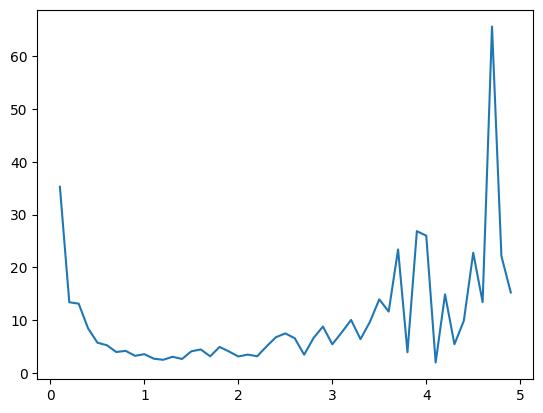

In [137]:
n = 100

vars = [impExp(n,l) for l in np.arange(0.1, 5, 0.1)]

plt.plot(np.arange(0.1, 5, 0.1), vars)
plt.show()

## Part 9

Explained theoretically